In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
from sklearn.metrics import classification_report

import keras
from keras import layers
from keras import losses
from keras import metrics
from keras import optimizers
from keras import datasets

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [4]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

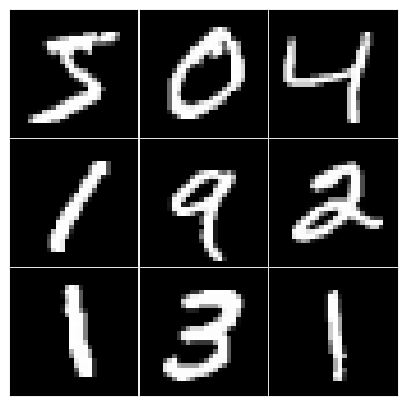

In [5]:
def plot_9_images(images, labels):
    fig, axes = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.01, wspace=0.01)

    num_images = images.shape[0]
    for i in range(num_images):
        axes.flatten()[i].imshow(images[i], cmap="Greys_r")
        axes.flatten()[i].set_xticks([])
        axes.flatten()[i].set_yticks([])

    fig.show()
    return


plot_9_images(x_train[:9], y_train[:9])

In [6]:
def minmax_scaling(x, min_val=0, max_val=255):
    x_scaled = (x - min_val) / max_val
    x_scaled = x_scaled[..., None]
    return x_scaled

x_train_scaled = minmax_scaling(x_train)
x_test_scaled = minmax_scaling(x_test)

In [7]:
x_train_scaled.min(), x_train_scaled.max()

(np.float64(0.0), np.float64(1.0))

In [8]:
x_test_scaled.min(), x_test_scaled.max()

(np.float64(0.0), np.float64(1.0))

In [9]:
x_train_scaled.shape[1:]

(28, 28, 1)

In [14]:
model = keras.models.Sequential()
model.add(layers.InputLayer(shape=x_train_scaled.shape[1:]))
model.add(layers.Conv2D(32, (9, 9), activation="relu"))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(64, (5, 5), activation="relu"))
model.add(layers.MaxPooling2D())
model.add(layers.Flatten())
model.add(layers.Dense(256, activation="relu"))
model.add(layers.Dropout(0.20))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.20))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,698 (854.29 KB)

 Trainable params: 218,698 (854.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
loss = losses.SparseCategoricalCrossentropy()
opt = optimizers.Adam()
model.compile(optimizer=opt, loss=loss, metrics=["accuracy"])

In [16]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=25,
    batch_size=128,
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6004 - loss: 2.5744 - val_accuracy: 0.9698 - val_loss: 0.1044
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9635 - loss: 0.1260 - val_accuracy: 0.9787 - val_loss: 0.0726
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9778 - loss: 0.0799 - val_accuracy: 0.9843 - val_loss: 0.0621
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9839 - loss: 0.0560 - val_accuracy: 0.9860 - val_loss: 0.0527
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9856 - loss: 0.0504 - val_accuracy: 0.9852 - val_loss: 0.0535
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9877 - loss: 0.0425 - val_accuracy: 0.9859 - val_loss: 0.0592
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9870 - loss: 0.0487 - val_accuracy: 0.9843 - val_loss: 0.0660
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0371 - val_accuracy: 0.

In [17]:
p_test = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
p_test_argmax = np.argmax(p_test, axis=1)

In [26]:
p_test_argmax[:9]

array([7, 2, 1, 0, 4, 1, 4, 9, 5])

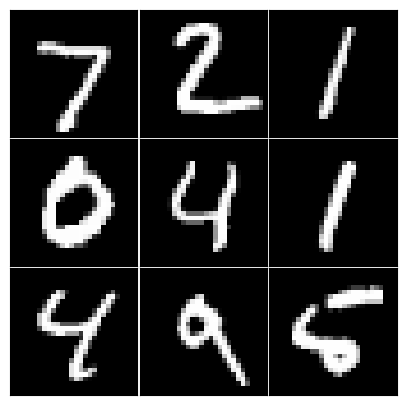

In [24]:
plot_9_images(x_test[:9], y_test[:9])

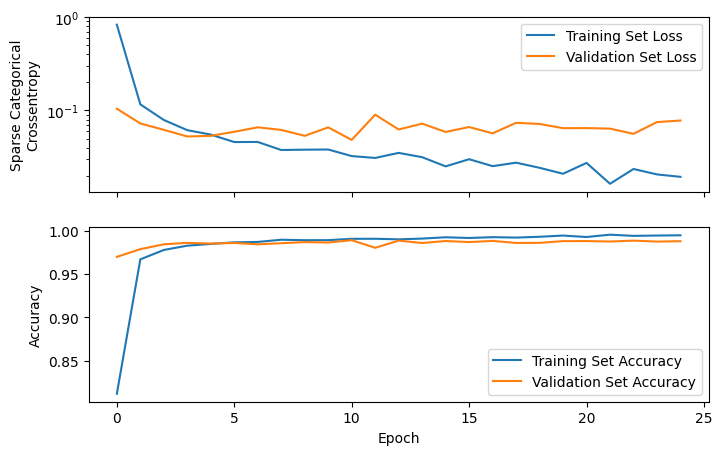

In [29]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 5))

axes[0].semilogy(history.history["loss"], label="Training Set Loss")
axes[0].semilogy(history.history["val_loss"], label="Validation Set Loss")
axes[0].legend(loc="upper right")

axes[1].plot(history.history["accuracy"], label="Training Set Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Set Accuracy")
axes[1].legend(loc="lower right")
# axes[1].set_ylim((0, 1))

axes[1].set_xlabel("Epoch")

axes[0].set_ylabel("Sparse Categorical\nCrossentropy")
axes[1].set_ylabel("Accuracy")

fig.show()

In [31]:
print(classification_report(y_test, p_test_argmax))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      1.00      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       0.98      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

